# 3D halo power spectrum

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [3]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean_gal_all = pickle.load(f)
    Pk_gal_all = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'ps_data/snap40/mvir/ps-intensity-gal_all.pickle'

In [4]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [ ]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_cent10 = pickle.load(f)

In [4413]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat10 = pickle.load(f)
print("shotnoise", Pk_sat10.attrs["shotnoise"])

shotnoise 352.60039701132393


In [5]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [6]:
iend = 200

In [7]:
from nbodykit import cosmology

cosmo1 = cosmology.Planck15
z=1.5
Plin = cosmology.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology.power.halofit.HalofitPower(cosmo1, redshift=z) 

#k_analytical = 10**np.arange(-1.6,0,0.05)
#k_colossus = 10**np.arange(-3,0,0.02)
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear = Plin(ks)
normed_Pk_matter_lin = coef * Pk_linear 
Pk_nonlinear = Pnl(ks)
normed_Pk_matter_nl = coef * Pk_nonlinear 

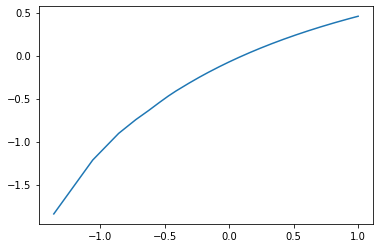

In [12]:
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


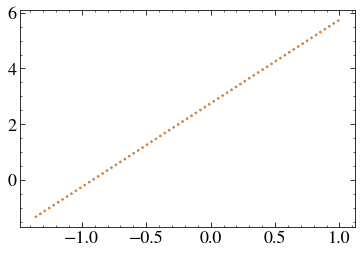

In [4738]:
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:i]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:i]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


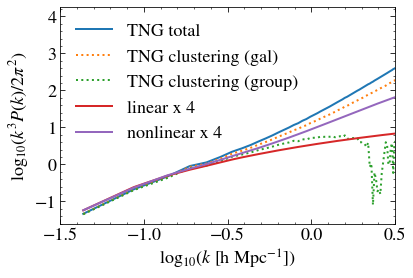

In [4745]:
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total")
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)")
plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)")

plt.plot(np.log10(ks), np.log10(4*normed_Pk_matter_lin), label="linear x 4")
plt.plot(np.log10(ks), np.log10(4*normed_Pk_matter_nl), label="nonlinear x 4")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
plt.xlim(-1.5, 0.5)
plt.legend()


#plt.savefig("figures/tng_vs_matterx4.pdf", format="pdf", bbox_inches="tight")

In [11]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [70]:
ic = 3
pkgal1_ratio = coef[ic] * (Pk_gal10["power"][:iend])[ic]/normed_Pk_matter_lin[ic]
pkgal2_ratio = coef[ic] * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])[ic]/normed_Pk_matter_lin[ic]

pkgal3_ratio = coef[ic] * (Pk_gal10["power"][:iend]-2*Pk_sum10.attrs["shotnoise"])[ic]/normed_Pk_matter_lin[ic]
print(pkgal1_ratio)
print(pkgal2_ratio)
#pksum1_ratio = coef[0] * (Pk_sum10["power"][:i])[0]/normed_Pk_matter_lin[0]
#pksum2_ratio = coef[0] * (Pk_sum10["power"][:i]-Pk_sum10.attrs["shotnoise"])[0]/normed_Pk_matter_lin[0]
#print(pksum1_ratio)
#print(pksum2_ratio)

(5.0272005668068775+0j)
(4.782919318908629+0j)


In [8]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [10]:
color_list1 = palette_tab10[3:4] + ["gold"]

NameError: name 'palette_tab10' is not defined

In [79]:
with open(f"{odir}/snap40/mvir/number_density/logMmin12.pickle", "rb") as f:
    Pk_mean2 = pickle.load(f)
    Pk2 = pickle.load(f)

In [80]:
pkgal3_ratio = coef[0] * (Pk2["power"][:iend]-Pk2.attrs["shotnoise"])[0]/normed_Pk_matter_lin[0]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


NameError: name 'pkgal2_ratio' is not defined

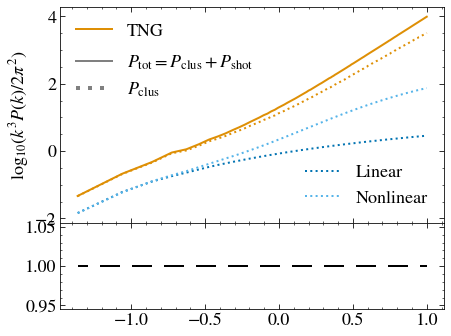

In [12]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear", "Nonlinear"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), coef * Pk_gal10["power"][:iend]/(pkgal2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/(pkgal2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks),(Pk_gal10["power"][:iend]-2*Pk_sum10.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
plt.plot(np.log10(ks),(Pk2["power"][:iend]-Pk2.attrs["shotnoise"])/(5*Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="green")


#plt.plot(np.log10(ks),np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pkgal2_ratio*Pk_linear)), linestyle="dotted", label="TNG clustering (gal)", color="purple")
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.plot(np.log10(ks), (Pk1["power"][:iend]-Pk1.attrs["shotnoise"])/(pkgal3_ratio*Pk_linear))

plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.7,2)
plt.ylabel("$C \cdot P/P_{linear}$")
#plt.savefig("figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

NameError: name 'color_list1' is not defined

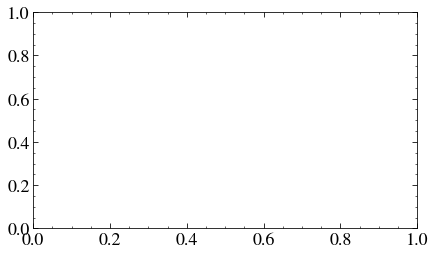

In [9]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear $P_\mathrm{m}$", "Nonlinear $P_\mathrm{m}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), np.sqrt(Pk_gal10["power"][:iend]/Pk_linear), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])

#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.plot(np.log10(ks), np.sqrt(normed_Pk_matter_nl/normed_Pk_matter_lin), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.9,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")
#plt.savefig("../figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dt

Text(0, 0.5, '$(P/P_{\\mathrm{linear}})^{1/2}$')

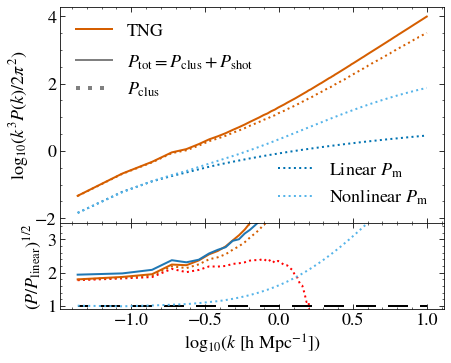

In [49]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear $P_\mathrm{m}$", "Nonlinear $P_\mathrm{m}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), np.sqrt(Pk_gal10["power"][:iend]/Pk_linear), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.9,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")
#plt.savefig("../figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

In [47]:
with open(f"{odir}/snap40/mvir/gal_survey/logSFR0.9186.pickle", "rb") as f:
    Pk_mean1 = pickle.load(f)
    Pk1 = pickle.load(f)

In [37]:
np.log10(ks[:13])

array([-1.36238137, -1.06033514, -0.85899556, -0.72547219, -0.62661139,
       -0.54272912, -0.473019  , -0.41424163, -0.36117288, -0.31354678,
       -0.27102314, -0.23226579, -0.19665425])

In [36]:
np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear)

array([ 1.78491542+0.j,  1.84956538+0.j,  1.91521969+0.j,  2.18698864+0.j,
        2.13506421+0.j,  2.24776298+0.j,  2.40080076+0.j,  2.46037294+0.j,
        2.5519296 +0.j,  2.68708906+0.j,  2.79271506+0.j,  2.9123465 +0.j,
        3.05594473+0.j,  3.17448358+0.j,  3.29143316+0.j,  3.44267543+0.j,
        3.50902005+0.j,  3.68774129+0.j,  3.7646974 +0.j,  3.94468216+0.j,
        4.06356133+0.j,  4.17881166+0.j,  4.3373279 +0.j,  4.46419355+0.j,
        4.6054191 +0.j,  4.70862543+0.j,  4.86325441+0.j,  4.9852348 +0.j,
        5.16025562+0.j,  5.28991921+0.j,  5.42429793+0.j,  5.62988732+0.j,
        5.69816469+0.j,  5.86367654+0.j,  6.03079729+0.j,  6.18738188+0.j,
        6.32909877+0.j,  6.4897494 +0.j,  6.59311601+0.j,  6.76184655+0.j,
        6.90117359+0.j,  7.09705317+0.j,  7.23676454+0.j,  7.42488966+0.j,
        7.47423254+0.j,  7.67919328+0.j,  7.78400616+0.j,  8.00987676+0.j,
        8.13045148+0.j,  8.28877426+0.j,  8.46119753+0.j,  8.63229475+0.j,
        8.76345033+0.j,  

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(0.0, 2.0)

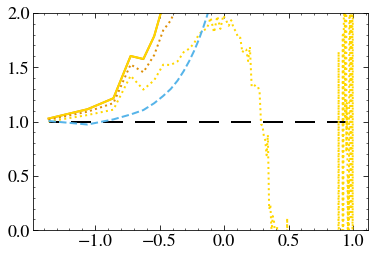

In [4764]:
linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), coef * Pk_gal10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks),coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.plot(np.log10(ks), normed_Pk_matter_nl/normed_Pk_matter_lin, label="nonlinear x 4", color = color_list2[1], linestyle="dashed")

#plt.xlim(-1.5,-0.5)
plt.ylim(0,2)

In [2873]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM11.5-12.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal_logM = pickle.load(f)
print("shotnoise", Pk_sum_logM.attrs["shotnoise"])

shotnoise 240.71354944234457


In [1746]:
arr = np.arange(11.5, 12.1, 0.1)
logM_names = [f"logM{i:.1f}-{e:.1f}" for (i,e) in zip(arr[:-1], arr[2:])]

In [1724]:
print(logM_names)

['logM11.5-11.6', 'logM11.6-11.7', 'logM11.7-11.8', 'logM11.8-11.9', 'logM11.9-12.0']


In [2830]:
logM_names = ["logM11-11.5", "logM11.5-12", "logM12-12.5", "logM12.5-13"][2:]

In [3126]:
logM_names = ["logMmax11", "logM11-13", "logMmin13"]

In [2831]:
Pk_gal_logM_list = []
for logM in logM_names:
    with open(f"{odir}/snap40/mvir/ps-intensity-gal_{logM}.pickle", "rb") as f:
        Pk_mean_gal10 = pickle.load(f)
        Pk_gal_logM = pickle.load(f)
    Pk_gal_logM_list.append(Pk_sum_logM)

FileNotFoundError: [Errno 2] No such file or directory: 'ps_data/snap40/mvir/ps-intensity-gal_logM12-12.5.pickle'